In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pokemon-images-and-types/pokemon.csv
/kaggle/input/pokemon-images-and-types/images/throh.png
/kaggle/input/pokemon-images-and-types/images/samurott.png
/kaggle/input/pokemon-images-and-types/images/venomoth.png
/kaggle/input/pokemon-images-and-types/images/latios.png
/kaggle/input/pokemon-images-and-types/images/shinx.png
/kaggle/input/pokemon-images-and-types/images/durant.png
/kaggle/input/pokemon-images-and-types/images/primarina.png
/kaggle/input/pokemon-images-and-types/images/geodude.png
/kaggle/input/pokemon-images-and-types/images/popplio.png
/kaggle/input/pokemon-images-and-types/images/wingull.png
/kaggle/input/pokemon-images-and-types/images/miltank.png
/kaggle/input/pokemon-images-and-types/images/castform.png
/kaggle/input/pokemon-images-and-types/images/squirtle.png
/kaggle/input/pokemon-images-and-types/images/shaymin-land.png
/kaggle/input/pokemon-images-and-types/images/raikou.png
/kaggle/input/pokemon-images-and-types/images/guzzlord.png
/kaggle/input/po

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('/kaggle/input/pokemon-images-and-types/pokemon.csv')

In [4]:
df

,Name,Type1,Type2,Evolution
0,bulbasaur,Grass,Poison,ivysaur
1,ivysaur,Grass,Poison,venusaur
2,venusaur,Grass,Poison,NaN
3,charmander,Fire,NaN,charmeleon
4,charmeleon,Fire,NaN,charizard
...,...,...,...,...
804,stakataka,Rock,Steel,NaN
805,blacephalon,Fire,Ghost,NaN
806,zeraora,Electric,NaN,NaN
807,meltan,Steel,NaN,NaN


In [5]:
df.isnull()

,Name,Type1,Type2,Evolution
0,False,False,False,False
1,False,False,False,False
2,False,False,False,True
3,False,False,True,False
4,False,False,True,False
...,...,...,...,...
804,False,False,False,True
805,False,False,False,True
806,False,False,True,True
807,False,False,True,True


In [6]:
df.isnull().sum()

Name           0
Type1          0
Type2        404
Evolution    777
dtype: int64

In [7]:
print(os.listdir('../input'))

['pokemon-images-and-types']


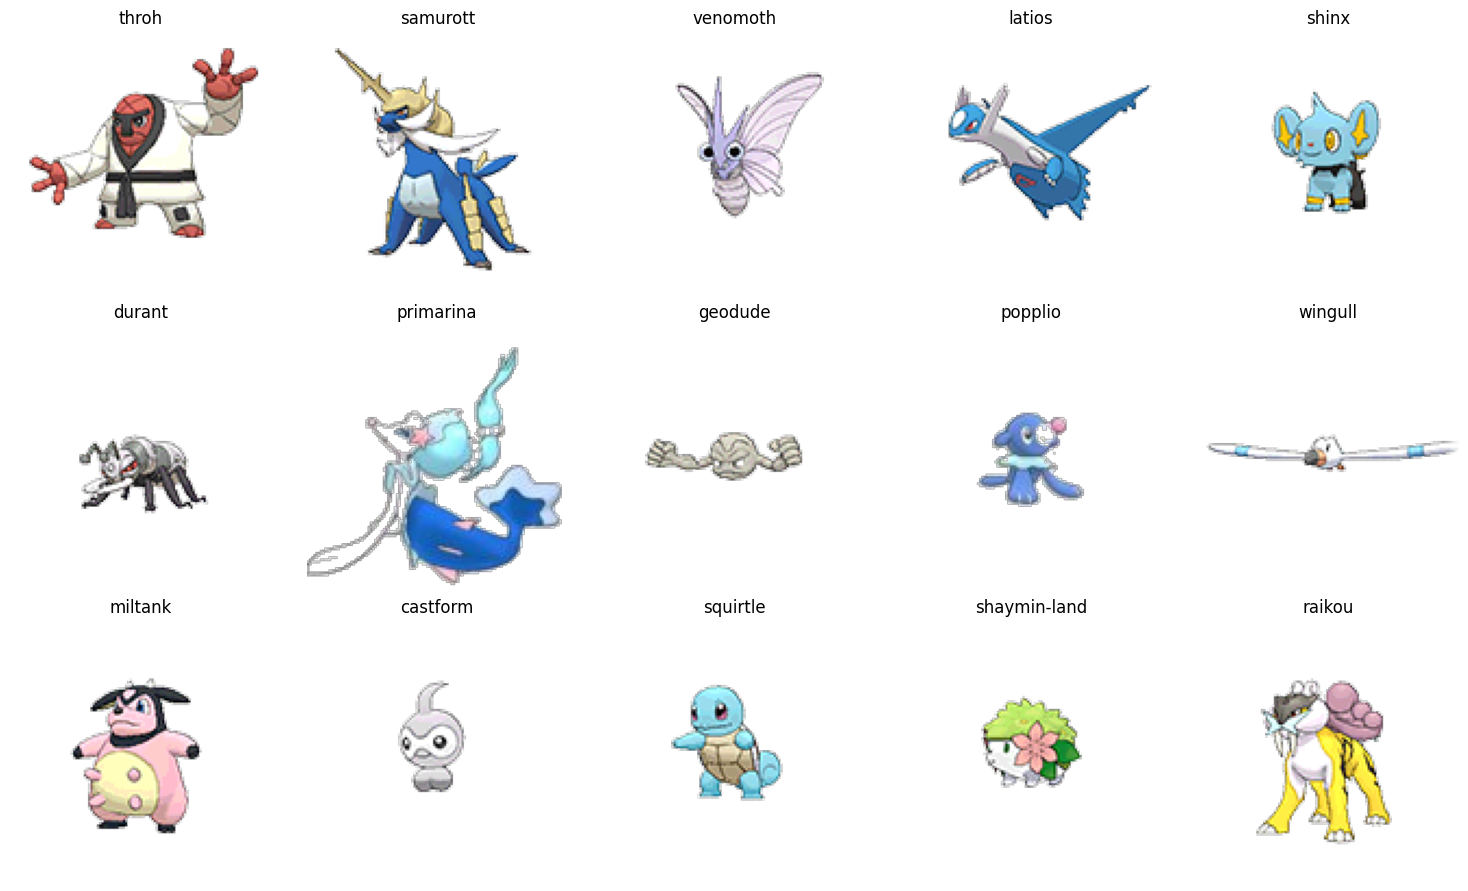

In [8]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Directory containing your images
image_folder = '/kaggle/input/pokemon-images-and-types/images'

# List all image file paths
image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(('png', 'jpg', 'jpeg'))]

# Limit to first 15 images (5 images per row for 3 rows)
image_paths = image_paths[:15]

# Display the images with their file names (without extensions)
plt.figure(figsize=(15, 9))  # Adjust the figure size to fit 15 images nicely

for i, image_path in enumerate(image_paths):
    # Load the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image)
    
    # Get the file name without the extension
    file_name = os.path.splitext(os.path.basename(image_path))[0]
    
    # Subplot for each image (3 rows, 5 columns)
    plt.subplot(3, 5, i + 1)
    plt.imshow(image)
    plt.title(file_name)  # Display the file name without extension as the title
    plt.axis('off')  # No axes for a cleaner look

# Show all images
plt.tight_layout()
plt.show()


In [9]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [10]:
# Paths to dataset
data_folder = '/kaggle/input/pokemon-images-and-types'
images_folder = os.path.join(data_folder, 'images')
metadata_file = os.path.join(data_folder, 'pokemon.csv')

In [11]:
# Load metadata
metadata = pd.read_csv(metadata_file)


In [12]:
# Preprocess image data
def preprocess_image(image_path, label, img_size=(128, 128)):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0  # Normalize to [0, 1]
    return image, label


In [13]:
# Convert labels to one-hot encoding
labels = metadata['Type1'].unique()
label_map = {label: idx for idx, label in enumerate(labels)}
metadata['Label'] = metadata['Type1'].map(label_map)
num_classes = len(labels)

In [14]:
# Prepare dataset
images = []
labels_list = []


In [15]:
for _, row in metadata.iterrows():
    image_path = os.path.join(images_folder, row['Name'] + '.png')  # Ensure the file extension matches
    if os.path.exists(image_path):  # Check if the image file exists
        image, label = preprocess_image(image_path, row['Label'])
        images.append(image.numpy())  # Convert TensorFlow tensor to NumPy array
        labels_list.append(label)

images = np.array(images)  # Convert list of arrays to a single NumPy array
labels = np.array(labels_list)


In [16]:

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)



In [17]:
# Define the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [19]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val))


Epoch 1/100


I0000 00:00:1726152430.454362      80 service.cc:145] XLA service 0x79f40c004b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1726152430.454429      80 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1066 - loss: 2.8323

I0000 00:00:1726152433.389740      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1111 - loss: 2.8215

I0000 00:00:1726152434.895196      81 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_2', 64 bytes spill stores, 64 bytes spill loads



21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.1120 - loss: 2.8191 - val_accuracy: 0.1481 - val_loss: 2.7647
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2038 - loss: 2.5465 - val_accuracy: 0.1235 - val_loss: 2.8549
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2996 - loss: 2.2170 - val_accuracy: 0.1420 - val_loss: 2.9488
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4426 - loss: 1.7416 - val_accuracy: 0.1296 - val_loss: 3.5340
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6484 - loss: 1.0948 - val_accuracy: 0.1296 - val_loss: 4.0574
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8031 - loss: 0.6417 - val_accuracy: 0.0926 - val_loss: 5.1417
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8659 - loss: 0.3928 - val_accuracy: 0.0988 - val_loss: 5.9484
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9282 - loss: 0.2249 - val_accuracy: 0.0802 - val_

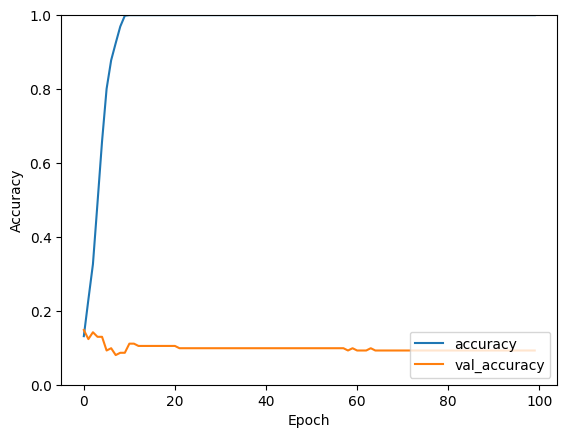

In [20]:
# Plot training history (optional)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [21]:
# Save the model
model.save('/kaggle/working/model.h5')
